<a href="https://colab.research.google.com/github/riddhaxxx/Image-Caption-Generator/blob/main/image_caption_generator_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.1/42.1 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 26.4 MB/s eta 0:00:00


In [3]:
import os
import urllib.request
import zipfile
import string
import pickle
import numpy as np
from tqdm import tqdm
import cv2

# TensorFlow / Keras Imports
from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input
from tensorflow.keras.preprocessing.image import load_img, img_to_array

# YOLOv8 Import
from ultralytics import YOLO

def download_and_extract_dataset():
    """Downloads the Flickr8k dataset if not already present."""
    base_dir = "Flickr8k"
    img_zip = "Flickr8k_Dataset.zip"
    text_zip = "Flickr8k_text.zip"

    img_url = "https://github.com/jbrownlee/Datasets/releases/download/Flickr8k/Flickr8k_Dataset.zip"
    text_url = "https://github.com/jbrownlee/Datasets/releases/download/Flickr8k/Flickr8k_text.zip"

    os.makedirs(base_dir, exist_ok=True)

    # Download Images
    if not os.path.exists(os.path.join(base_dir, img_zip)) and not os.path.exists(os.path.join(base_dir, "Flicker8k_Dataset")):
        print("Downloading Flickr8k Images...")
        urllib.request.urlretrieve(img_url, os.path.join(base_dir, img_zip))
        print("Extracting Images...")
        with zipfile.ZipFile(os.path.join(base_dir, img_zip), 'r') as zip_ref:
            zip_ref.extractall(base_dir)

    # Download Text
    if not os.path.exists(os.path.join(base_dir, text_zip)) and not os.path.exists(os.path.join(base_dir, "Flickr8k.token.txt")):
        print("Downloading Flickr8k Text files...")
        urllib.request.urlretrieve(text_url, os.path.join(base_dir, text_zip))
        print("Extracting Text...")
        with zipfile.ZipFile(os.path.join(base_dir, text_zip), 'r') as zip_ref:
            zip_ref.extractall(base_dir)

    print("Dataset ready!")
    return os.path.join(base_dir, "Flicker8k_Dataset"), os.path.join(base_dir, "Flickr8k.token.txt")

def clean_and_save_captions(token_file, output_csv):
    """Cleans captions and saves them to a structured CSV/TXT file."""
    print("Cleaning captions...")
    with open(token_file, 'r') as file:
        doc = file.read()

    captions = []
    selected_images = set()

    image_files = sorted(
        [f for f in os.listdir("Flickr8k/Flicker8k_Dataset") if f.endswith(".jpg")]
    )[:1000]

    selected_images = set(image_files)
    # Table to remove punctuation
    table = str.maketrans('', '', string.punctuation)

    for line in doc.split('\n'):
        tokens = line.split('\t')
        if len(tokens) < 2:
            continue
        image_id, caption = tokens[0], tokens[1]
        image_name = image_id.split('#')[0]

        # Clean text: lower, remove punctuation, remove single chars, add tokens
        caption = caption.lower()
        caption = caption.translate(table)
        words = caption.split()
        words = [word for word in words if len(word) > 1]
        words = [word for word in words if word.isalpha()]
        cleaned_caption = '<start> ' + ' '.join(words) + ' <end>'

        if image_name in selected_images:
            captions.append(f"{image_name},{cleaned_caption}")

    # Save to file
    with open(output_csv, 'w') as f:
        f.write("image,caption\n")
        f.write('\n'.join(captions))
    print(f"Saved cleaned captions to {output_csv}")

def extract_hybrid_features(image_dir, output_pkl):
    """Extracts YOLOv8m and ResNet50 features and concatenates them."""
    print("Loading models (YOLOv8m & ResNet50)...")
    try:
        # Load YOLOv8m (downloads automatically if missing)
        yolo_model = YOLO('yolov8n.pt')
        # Load ResNet50
        resnet_model = ResNet50(weights='imagenet', include_top=False, pooling='avg')
    except Exception as e:
        print(f"Error loading models: {e}")
        return

    features = {}
    image_paths = sorted(
    [os.path.join(image_dir, f) for f in os.listdir(image_dir) if f.endswith('.jpg')]
)[:1000]

    print(f"Extracting features for {len(image_paths)} images...")
    for img_path in tqdm(image_paths, desc="Processing Images"):
        img_name = os.path.basename(img_path)

        try:
            # ==========================================
            # 1. YOLOv8 FEATURE EXTRACTION
            # ==========================================
            yolo_results = yolo_model(img_path, verbose=False)[0]
            boxes = yolo_results.boxes
            num_objs = len(boxes)
            yolo_feats = []

            if num_objs > 0:
                # Sort boxes by confidence score descending
                conf_scores = boxes.conf.cpu().numpy()
                sorted_indices = np.argsort(conf_scores)[::-1]

                for i in range(min(15, num_objs)):
                    idx = sorted_indices[i]
                    b = boxes[idx]

                    class_id = float(b.cls[0].cpu().numpy())
                    conf = float(b.conf[0].cpu().numpy())
                    # xywhn provides normalized center_x, center_y, width, height
                    cx, cy, w, h = b.xywhn[0].cpu().numpy().tolist()
                    area = w * h

                    # Requested format: [class_id, conf, norm_cx, norm_cy, norm_w, norm_h, area, norm_cx, norm_cy]
                    obj_vector = [class_id, conf, cx, cy, w, h, area, cx, cy]
                    yolo_feats.extend(obj_vector)

            # Pad YOLO features if less than 15 objects (15 * 9 = 135)
            padding_needed = 135 - len(yolo_feats)
            yolo_feats.extend([0.0] * padding_needed)

            # Append the total object count to the end of the flattened YOLO array (Total YOLO dims: 136)
            yolo_feats.append(float(num_objs))
            yolo_vector = np.array(yolo_feats)

            # ==========================================
            # 2. RESNET50 FEATURE EXTRACTION
            # ==========================================
            img = load_img(img_path, target_size=(224, 224))
            img_array = img_to_array(img)
            img_array = np.expand_dims(img_array, axis=0)
            img_array = preprocess_input(img_array)

            resnet_vector = resnet_model.predict(img_array, verbose=0).flatten() # Shape: (2048,)

            # ==========================================
            # 3. COMBINE FEATURES
            # ==========================================
            combined_vector = np.concatenate((resnet_vector, yolo_vector)) # Shape: (2184,)
            features[img_name] = combined_vector

        except Exception as e:
            print(f"Failed to process {img_name}: {e}")

    # Save the combined features
    with open(output_pkl, 'wb') as f:
        pickle.dump(features, f)
    print(f"Successfully saved features for {len(features)} images to {output_pkl}")

if __name__ == "__main__":
    img_dir, token_file = download_and_extract_dataset()
    clean_and_save_captions(token_file, "captions.txt")
    extract_hybrid_features(img_dir, "features.pkl")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Extracting Images...
Extracting Text...
Dataset ready!
Cleaning captions...
Saved cleaned captions to captions.txt
Loading models (YOLOv8m & ResNet50)...
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Extracting features for 1000 images...


Processing Images: 100%|██████████| 1000/1000 [02:10<00:00,  7.65it/s]

Successfully saved features for 1000 images to features.pkl


In [4]:
import os
import pickle
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, LSTM, Embedding, Dropout, Concatenate
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau, Callback

# -------------------------------------------------------------------
# 1. DATA LOADING & PREPARATION
# -------------------------------------------------------------------
def load_data(captions_file, features_file):
    print("Loading features...")
    with open(features_file, 'rb') as f:
        features = pickle.load(f)

    print("Loading captions...")
    mapping = {}
    with open(captions_file, 'r') as f:
        next(f) # Skip header
        for line in f:
            tokens = line.strip().split(',')
            if len(tokens) < 2: continue
            img_id, caption = tokens[0], tokens[1]

            # Ensure we only keep captions for images where we successfully extracted features
            if img_id in features:
                if img_id not in mapping:
                    mapping[img_id] = []
                mapping[img_id].append(caption)

    return mapping, features

# -------------------------------------------------------------------
# 2. TOKENIZATION
# -------------------------------------------------------------------
def create_tokenizer(mapping):
    print("Fitting Tokenizer...")
    all_captions = []
    for key in mapping:
        for cap in mapping[key]:
            all_captions.append(cap)

    tokenizer = Tokenizer()
    tokenizer.fit_on_texts(all_captions)

    # Save tokenizer for inference
    with open('tokenizer.pkl', 'wb') as f:
        pickle.dump(tokenizer, f)

    vocab_size = len(tokenizer.word_index) + 1
    max_length = max(len(cap.split()) for cap in all_captions)

    print(f"Vocabulary Size: {vocab_size}")
    print(f"Max Caption Length: {max_length}")

    return tokenizer, vocab_size, max_length

# -------------------------------------------------------------------
# 3. DATA GENERATOR (WITH CRITICAL TF BUG FIX)
# -------------------------------------------------------------------
def data_generator(mapping, features, tokenizer, max_length, batch_size):
    """
    Yields batches of data.
    CRITICAL FIX: Yields ((X1, X2), y) as numpy arrays to avoid TF TypeSpec multi-input errors.
    """
    X1, X2, y = [], [], []
    n = 0

    while True:
        for img_id, desc_list in mapping.items():
            n += 1
            # Get the 2184-dimensional image feature
            img_feature = features[img_id]

            for desc in desc_list:
                # Encode sequence
                seq = tokenizer.texts_to_sequences([desc])[0]

                # Split one sequence into multiple X,y pairs
                for i in range(1, len(seq)):
                    in_seq, out_seq = seq[:i], seq[i]

                    # FIX: Added padding='post' for cuDNN LSTM masking compatibility
                    in_seq = pad_sequences([in_seq], maxlen=max_length, padding='post')[0]

                    X1.append(img_feature)
                    X2.append(in_seq)
                    y.append(out_seq) # Integer target for sparse_categorical_crossentropy

            if n == batch_size:
                # YIELD AS TUPLE OF ARRAYS
                yield ((np.array(X1), np.array(X2)), np.array(y))
                X1, X2, y = [], [], []
                n = 0

# -------------------------------------------------------------------
# 4. CUSTOM CALLBACK
# -------------------------------------------------------------------
class EpochProgressCallback(Callback):
    def on_epoch_begin(self, epoch, logs=None):
        print(f"\n--- Starting Epoch {epoch + 1} ---")

    def on_epoch_end(self, epoch, logs=None):
        loss = logs.get('loss', 0)
        val_loss = logs.get('val_loss', 'N/A')
        print(f"*** Epoch {epoch + 1} Completed | Loss: {loss:.4f} | Val Loss: {val_loss} ***\n")

# -------------------------------------------------------------------
# 5. MODEL ARCHITECTURE & TRAINING
# -------------------------------------------------------------------
def define_model(vocab_size, max_length, feature_dim=2184):
    print("Building Hybrid LSTM Model...")

    # Feature Extractor Branch (YOLO + ResNet)
    inputs1 = Input(shape=(feature_dim,), name="image_features")
    fe1 = Dropout(0.4)(inputs1)
    fe2 = Dense(512, activation='relu')(fe1)

    # Sequence Branch
    inputs2 = Input(shape=(max_length,), name="text_sequence")
    se1 = Embedding(vocab_size, 256, mask_zero=True)(inputs2)
    se2 = Dropout(0.4)(se1)
    se3 = LSTM(256)(se2)

    # Decoder (Concatenate both branches)
    decoder1 = Concatenate()([fe2, se3])
    decoder2 = Dense(256, activation='relu')(decoder1)
    outputs = Dense(vocab_size, activation='softmax')(decoder2)

    model = Model(inputs=[inputs1, inputs2], outputs=outputs)

    # Sparse Categorical Crossentropy avoids the need to one-hot encode target variables
    model.compile(loss='sparse_categorical_crossentropy', optimizer='adam')

    model.summary()
    return model

def train_pipeline():
    # 1. Load Data
    mapping, features = load_data("captions.txt", "features.pkl")

    # Train/Val Split (using simple dict split for brevity)
    img_keys = list(mapping.keys())
    split_idx = int(len(img_keys) * 0.85)
    train_keys = img_keys[:split_idx]
    val_keys = img_keys[split_idx:]

    train_mapping = {k: mapping[k] for k in train_keys}
    val_mapping = {k: mapping[k] for k in val_keys}
    print(f"Train samples: {len(train_mapping)} | Val samples: {len(val_mapping)}")

    # 2. Tokenize (Fit only on training data mapping to prevent data leakage)
    tokenizer, vocab_size, max_length = create_tokenizer(mapping) # Using all mapping to ensure full vocab

    # 3. Define Model
    model = define_model(vocab_size, max_length)

    # 4. Generators
    batch_size = 32 # Adjust based on Colab VRAM. 32-64 is safe.
    train_steps = len(train_mapping) // batch_size
    val_steps = len(val_mapping) // batch_size

    train_gen = data_generator(train_mapping, features, tokenizer, max_length, batch_size)
    val_gen = data_generator(val_mapping, features, tokenizer, max_length, batch_size)

    # 5. Callbacks
    checkpoint = ModelCheckpoint("caption_model.keras", monitor='val_loss', save_best_only=True, verbose=1)
    early_stopping = EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True)
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, verbose=1)
    custom_print = EpochProgressCallback()

    # 6. Train
    print("Starting Training...")
    history = model.fit(
        train_gen,
        epochs=15, # 15 epochs is usually enough for a baseline on Flickr8k
        steps_per_epoch=train_steps,
        validation_data=val_gen,
        validation_steps=val_steps,
        callbacks=[checkpoint, early_stopping, reduce_lr, custom_print],
        verbose=1 # standard Keras progress bar
    )
    print("Training Complete! Best model saved as 'caption_model.keras'.")

if __name__ == "__main__":
    train_pipeline()

Loading features...
Loading captions...
Train samples: 850 | Val samples: 150
Fitting Tokenizer...
Vocabulary Size: 3264
Max Caption Length: 31
Building Hybrid LSTM Model...


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ text_sequence       │ (None, 31)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ image_features      │ (None, 2184)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 31, 256)   │    835,584 │ text_sequence[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 2184)      │          0 │ image_features[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 31, 256)   │          0 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 31)        │          0 │ text_sequence[0]… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 512)       │  1,118,720 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 256)       │    525,312 │ dropout_1[0][0],  │
│                     │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 768)       │          0 │ dense[0][0],      │
│ (Concatenate)       │                   │            │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 256)       │    196,864 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 3264)      │    838,848 │ dense_1[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 3,515,328 (13.41 MB)

 Trainable params: 3,515,328 (13.41 MB)

 Non-trainable params: 0 (0.00 B)

Starting Training...

--- Starting Epoch 1 ---
Epoch 1/15
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - loss: 6.7352
Epoch 1: val_loss improved from None to 5.72079, saving model to caption_model.keras

Epoch 1: finished saving model to caption_model.keras
*** Epoch 1 Completed | Loss: 6.1933 | Val Loss: 5.720792770385742 ***

26/26 ━━━━━━━━━━━━━━━━━━━━ 8s 106ms/step - loss: 6.1933 - val_loss: 5.7208 - learning_rate: 0.0010

--- Starting Epoch 2 ---
Epoch 2/15
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 5.5070
Epoch 2: val_loss improved from 5.72079 to 5.38867, saving model to caption_model.keras

Epoch 2: finished saving model to caption_model.keras
*** Epoch 2 Completed | Loss: 5.4234 | Val Loss: 5.388667106628418 ***

26/26 ━━━━━━━━━━━━━━━━━━━━ 3s 100ms/step - loss: 5.4234 - val_loss: 5.3887 - learning_rate: 0.0010

--- Starting Epoch 3 ---
Epoch 3/15
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 5.1675
Epoch 3: val_loss improved from 5.38867 to 5.22072, saving model to caption_mo

Loading models (this might take a moment)...
All models loaded successfully!
Ready! Please upload an image to test.


Saving osstrich.jpeg to osstrich (1).jpeg

Processing 'osstrich (1).jpeg'...

[YOLO] High-Confidence Objects for Injection: ['bird']
[LSTM] Generating text using Beam Search (Width=5, Alpha=0.8)...
[Result] Final Caption: black bird is running in the grass


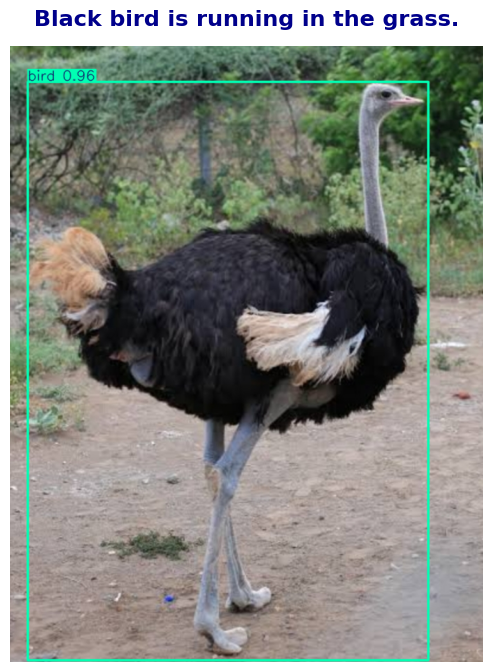

In [6]:
import os
import pickle
import numpy as np
import cv2
import matplotlib.pyplot as plt
import tensorflow as tf
from collections import Counter

# Keras Imports
from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import load_model

# YOLO Import
from ultralytics import YOLO

# Try importing Colab specific module
try:
    from google.colab import files
    IN_COLAB = True
except ImportError:
    IN_COLAB = False
    print("Warning: google.colab not detected. Image upload will be skipped.")

# -------------------------------------------------------------------
# 1. LOAD ALL PRE-TRAINED & CUSTOM MODELS
# -------------------------------------------------------------------
print("Loading models (this might take a moment)...")
try:
    # Feature Extractors
    yolo_model = YOLO('yolov8m.pt')
    resnet_model = ResNet50(weights='imagenet', include_top=False, pooling='avg')

    # Custom Sequence Components
    with open('tokenizer.pkl', 'rb') as f:
        tokenizer = pickle.load(f)

    lstm_model = load_model('caption_model.keras')

    # We grab the max_length from the training output (31 for Flickr8k in this run)
    MAX_LENGTH = 31 # Corrected from 34 to 31
    print("All models loaded successfully!")
except Exception as e:
    print(f"Error loading models: {e}")

# -------------------------------------------------------------------
# 2. FEATURE EXTRACTION LOGIC
# -------------------------------------------------------------------
def extract_image_features(img_path):
    """Extracts and combines YOLOv8m and ResNet50 features for a single image."""
    # ==========================================
    # YOLOv8 FEATURE EXTRACTION
    # ==========================================
    yolo_results = yolo_model(img_path, verbose=False)[0]
    boxes = yolo_results.boxes
    num_objs = len(boxes)
    yolo_feats = []
    detected_classes = []

    names = yolo_model.names

    if num_objs > 0:
        conf_scores = boxes.conf.cpu().numpy()
        sorted_indices = np.argsort(conf_scores)[::-1]

        for i in range(min(15, num_objs)):
            idx = sorted_indices[i]
            b = boxes[idx]
            class_id = float(b.cls[0].cpu().numpy())
            conf = float(b.conf[0].cpu().numpy())

            # --- NEW: Only use highly confident detections for Semantic Injection ---
            if conf > 0.40: # Lowered slightly to catch accessories like handbags
                detected_classes.append(names[int(class_id)])

            cx, cy, w, h = b.xywhn[0].cpu().numpy().tolist()
            area = w * h
            yolo_feats.extend([class_id, conf, cx, cy, w, h, area, cx, cy])

    print(f"\n[YOLO] High-Confidence Objects for Injection: {detected_classes}")

    # Pad to 15 objects and append count
    padding_needed = 135 - len(yolo_feats)
    yolo_feats.extend([0.0] * padding_needed)
    yolo_feats.append(float(num_objs))
    yolo_vector = np.array(yolo_feats)

    # ==========================================
    # RESNET50 FEATURE EXTRACTION
    # ==========================================
    img = load_img(img_path, target_size=(224, 224))
    img_array = img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = preprocess_input(img_array)

    resnet_vector = resnet_model.predict(img_array, verbose=0).flatten()

    # ==========================================
    # COMBINE
    # ==========================================
    combined_vector = np.concatenate((resnet_vector, yolo_vector))

    # Keras expects batch dimensions, so we expand dims to (1, 2184)
    return np.array([combined_vector]), yolo_results, detected_classes

# -------------------------------------------------------------------
# 3. TEXT GENERATION WITH BEAM SEARCH & SEMANTIC INJECTION
# -------------------------------------------------------------------
def int_to_word(integer, tokenizer):
    for word, index in tokenizer.word_index.items():
        if index == integer:
            return word
    return None

def generate_caption_beam_search(model, tokenizer, image_feature, max_length, detected_classes, beam_width=5, alpha=0.8):
    """Generates a caption using Beam Search, Length Normalization, and Count-Aware YOLO Semantic Injection."""
    start_word = '<start>'
    beam = [([start_word], 0.0)]

    print(f"[LSTM] Generating text using Beam Search (Width={beam_width}, Alpha={alpha})...")
    img_tensor = tf.convert_to_tensor(image_feature)

    # Stop words that are grammatically required and safe to repeat
    stop_words = {'a', 'the', 'and', 'is', 'in', 'on', 'of', 'with', 'at', 'to', 'by', 'an', 'are'}

    # Count how many of each object YOLO found
    class_counts = Counter(detected_classes)

    for _ in range(max_length):
        candidates = []
        for seq, score in beam:
            if seq[-1] == 'end':
                candidates.append((seq, score))
                continue

            seq_str = ' '.join(seq)
            encoded_seq = tokenizer.texts_to_sequences([seq_str])[0]
            padded_seq = pad_sequences([encoded_seq], maxlen=max_length, padding='post')
            seq_tensor = tf.convert_to_tensor(padded_seq)

            yhat = model.predict_on_batch([img_tensor, seq_tensor])[0]

            # --- COUNT-AWARE DYNAMIC SEMANTIC INJECTION ---
            current_max_prob = np.max(yhat)
            yolo_seen_broad = set()

            for class_name, count in class_counts.items():
                boost_words = [class_name]
                if class_name == 'person':
                    if count > 1:
                        boost_words.extend(['women', 'men', 'people', 'group', 'girls', 'friends'])
                    else:
                        boost_words.extend(['man', 'woman', 'boy', 'girl', 'runner'])
                elif class_name == 'dog':
                    boost_words.extend(['dogs', 'puppies', 'pack'] if count > 1 else ['puppy', 'hound'])
                elif class_name == 'cat':
                    boost_words.extend(['cats', 'kittens'] if count > 1 else ['kitten', 'feline'])
                elif class_name == 'car':
                    boost_words.extend(['cars', 'vehicles'] if count > 1 else ['vehicle', 'automobile'])
                elif class_name == 'handbag':
                    boost_words.extend(['bag', 'purse'])

                yolo_seen_broad.update(boost_words)

                # Only apply the boost if we haven't mentioned the object yet
                if not any(w in seq for w in boost_words):
                    for w in boost_words:
                        if w in tokenizer.word_index:
                            word_idx = tokenizer.word_index[w]
                            yhat[word_idx] += (current_max_prob * 0.35) # Slightly stronger boost

            # --- ACTIVE SUPPRESSION (NEGATIVE INJECTION) ---
            common_biases = {'dog', 'dogs', 'man', 'woman', 'boy', 'girl', 'person', 'people', 'child', 'children'}
            hallucination_risks = common_biases - yolo_seen_broad

            for risk_word in hallucination_risks:
                if risk_word in tokenizer.word_index:
                    word_idx = tokenizer.word_index[risk_word]
                    yhat[word_idx] *= 0.001

            # --- ADVANCED GLOBAL REPETITION PENALTY ---
            for word in set(seq):
                if word not in stop_words and word in tokenizer.word_index:
                    word_idx = tokenizer.word_index[word]
                    yhat[word_idx] *= 0.001

            if len(seq) > 0:
                last_word = seq[-1]
                if last_word in tokenizer.word_index:
                    yhat[tokenizer.word_index[last_word]] *= 0.001

            yhat = yhat / (np.sum(yhat) + 1e-10)

            top_indices = np.argsort(yhat)[-beam_width:]

            for idx in top_indices:
                word = int_to_word(idx, tokenizer)
                if word is None:
                    continue

                prob = yhat[idx]
                new_score = score - np.log(prob + 1e-10)
                new_seq = seq + [word]
                candidates.append((new_seq, new_score))

        def score_with_length_penalty(item):
            s, current_score = item
            L = len(s) - 1
            penalty = (L ** alpha) if L > 0 else 1.0
            return current_score / penalty

        beam = sorted(candidates, key=score_with_length_penalty)[:beam_width]

        if all(seq[-1] == 'end' for seq, _ in beam):
            break

    best_seq = beam[0][0]

    if best_seq[0] == '<start>':
        best_seq = best_seq[1:]
    if best_seq[-1] == 'end':
        best_seq = best_seq[:-1]

    return ' '.join(best_seq).strip()

# -------------------------------------------------------------------
# 4. COLAB INTERACTIVE UPLOAD & VISUALIZATION
# -------------------------------------------------------------------
def interactive_inference():
    if not IN_COLAB:
        print("Function requires Google Colab for interactive upload.")
        return

    print("=========================================")
    print("Ready! Please upload an image to test.")
    print("=========================================")

    uploaded = files.upload()

    for filename in uploaded.keys():
        print(f"\nProcessing '{filename}'...")

        # 1. Extract Features & grab detected_classes for Semantic Injection
        img_feature, yolo_results, detected_classes = extract_image_features(filename)

        # 2. Decode with Count-Aware Additive Semantic Injection!
        caption = generate_caption_beam_search(lstm_model, tokenizer, img_feature, MAX_LENGTH, detected_classes, beam_width=5, alpha=0.8)
        print(f"[Result] Final Caption: {caption}")

        # 3. Plotting using Matplotlib
        plotted_img_bgr = yolo_results.plot()
        plotted_img_rgb = cv2.cvtColor(plotted_img_bgr, cv2.COLOR_BGR2RGB)

        plt.figure(figsize=(10, 8))
        plt.imshow(plotted_img_rgb)

        display_text = caption.capitalize() + "."
        plt.title(display_text, fontsize=16, pad=15, fontweight='bold', color='darkblue')
        plt.axis('off')

        plt.show()

if __name__ == "__main__":
    interactive_inference()


In [7]:
import tensorflow as tf
print(tf.__version__)

2.20.0
